In [31]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.image as mpimg
import cv2
from PIL import Image 
from  sklearn.model_selection import train_test_split
import numpy as np

In [32]:
base_path = r'D:\csv\archive (1)\data'

print(os.listdir(base_path))


['without_mask', 'with_mask']


In [33]:
with_mask_files = os.listdir(r'D:\csv\archive (1)\data\with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']


In [34]:
without_mask_files = os.listdir(r"D:\csv\archive (1)\data\without_mask")
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']


In [35]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [36]:
without_mask_path = os.path.join(base_path, 'without_mask')

print("Without Mask Images:", len(os.listdir(without_mask_path)))


Without Mask Images: 3828


In [37]:
without_mask_path = os.listdir(without_mask_path)

In [38]:
print(without_mask_path[0:5])
print(without_mask_path[0:-5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg', 'without_mask_1002.jpg', 'without_mask_1003.jpg', 'without_mask_1004.jpg', 'without_mask_1005.jpg', 'without_mask_1006.jpg', 'without_mask_1007.jpg', 'without_mask_1008.jpg', 'without_mask_1009.jpg', 'without_mask_101.jpg', 'without_mask_1010.jpg', 'without_mask_1011.jpg', 'without_mask_1012.jpg', 'without_mask_1013.jpg', 'without_mask_1014.jpg', 'without_mask_1015.jpg', 'without_mask_1016.jpg', 'without_mask_1017.jpg', 'without_mask_1018.jpg', 'without_mask_1019.jpg', 'without_mask_102.jpg', 'without_mask_1020.jpg', 'without_mask_1021.jpg', 'without_mask_1022.jpg', 'without_mask_1023.jpg', 'without_mask_1024.jpg', 'without_mask_1025.jpg', 'without_mask_1026.jpg', 'without_mask_1027.jpg', 'without_mask_1028.jpg', 'without_mask_1029.jpg', 'without_mas

In [39]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [40]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [41]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [60]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


#### Displaying the image

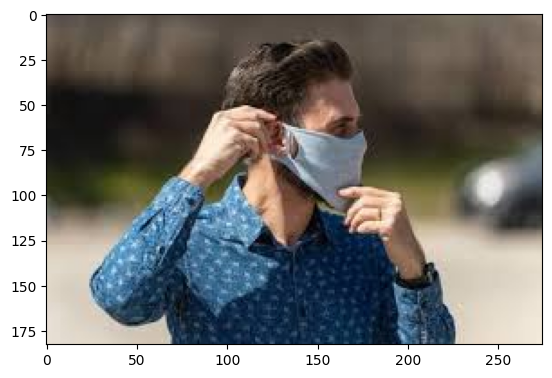

In [42]:
# displaying with mask images
img = mpimg.imread('D:/csv/archive (1)/data/with_mask/with_mask_2590.jpg')
imgplot = plt.imshow(img)
plt.show()

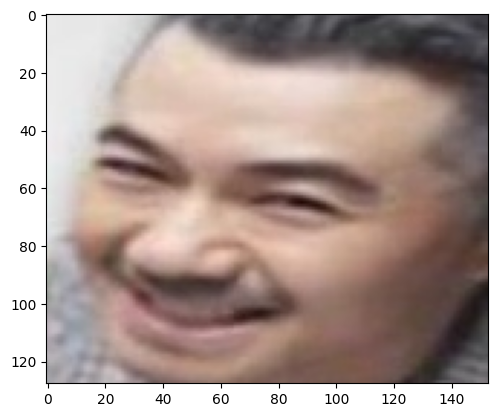

In [59]:
# displaying without mask images
img = mpimg.imread('D:/csv/archive (1)/data/without_mask/without_mask_200.jpg')
imgplot = plt.imshow(img)
plt.show()

### Image Processing

- resize images
- convert the images to numpy arrays

In [45]:
# convert images to numpy array

with_mask_path = r'D:\csv\archive (1)\data\with_mask/'
data = []
for img_file in with_mask_files:
    image = Image.open(with_mask_path + img_file) # open is for reading the image
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image) # create a tuple and resize the image to 128,128

without_mask_path = r'D:\csv\archive (1)\data\without_mask/'
for img_file in without_mask_files:
    image = Image.open(without_mask_path + img_file) # open is for reading the image
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image) # create a tuple and resize the image to 128,128



c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [47]:
type(data)

list

In [46]:
len(data)

7553

In [48]:
data[0]

array([[[50, 58, 31],
        [46, 55, 33],
        [56, 58, 42],
        ...,
        [27, 32, 25],
        [29, 33, 19],
        [33, 40, 17]],

       [[47, 54, 30],
        [49, 58, 36],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [37, 42, 31],
        [31, 41, 23]],

       [[51, 58, 37],
        [50, 59, 37],
        [59, 64, 37],
        ...,
        [45, 44, 30],
        [29, 34, 27],
        [20, 30, 18]],

       ...,

       [[63, 73, 37],
        [66, 75, 41],
        [74, 84, 50],
        ...,
        [ 5,  3,  0],
        [20, 19, 14],
        [17, 16, 12]],

       [[58, 72, 34],
        [60, 70, 39],
        [68, 75, 49],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 30],
        [53, 64, 37],
        [57, 64, 42],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [19, 12, 13]]], shape=(128, 128, 3), dtype=uint8)

In [49]:
type(data[0])

numpy.ndarray

In [50]:
data[0].shape

(128, 128, 3)

In [61]:
# converting image list and lable list to numpy array

X = np.array(data)
Y = np.array(labels)

In [62]:
type(X)

numpy.ndarray

In [63]:
type(Y)

numpy.ndarray

In [64]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [66]:
print(Y)

[1 1 1 ... 0 0 0]


Train Test Split

In [67]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [68]:
print(X.shape,X_train.shape,X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [69]:
# scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255